In [1]:
!pip install pandas gffutils

   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------------ --------------------------- 0.5/1.6 MB 217.9 kB/s eta 0:00:06
   ------------ --------------------------- 0.5/1.6 MB 217.9 kB/s eta 0:00:06
   ------------------- -------------------- 0.8/1.6 MB 305.0 kB/s eta 0:00:03
   ------------------- -------------------- 0.8/1.6 MB 305.0 kB/s eta 0:00:03
   ------------------- -------------------- 0.8/1.6 MB 305.0 kB/s eta 0:00:03
   ------------------- -------------------- 0.8/1.6 MB 305.0 kB/s eta 0:00:03
   ------------------------- -------------- 1.0/1


正在分析 DESeq2_Result_cluster0.csv...
  -> 找到 187 个严谨的显著位点，正在映射区域...

正在分析 DESeq2_Result_cluster1.csv...
  -> 找到 142 个严谨的显著位点，正在映射区域...

正在分析 DESeq2_Result_cluster2.csv...
  -> 找到 109 个严谨的显著位点，正在映射区域...

正在分析 DESeq2_Result_cluster3.csv...
  -> 找到 109 个严谨的显著位点，正在映射区域...

正在分析 DESeq2_Result_cluster4.csv...
  -> 找到 51 个严谨的显著位点，正在映射区域...

正在分析 DESeq2_Result_cluster5.csv...
  -> 找到 57 个严谨的显著位点，正在映射区域...

--- 各个 Cluster 显著位点的区域分布汇总 (数量与百分比) ---
 Cluster  Total_Sites       Intron  Intergenic      3' UTR Exon (Non-coding)    5' UTR       CDS
       0          187 113 (60.43%) 35 (18.72%) 27 (14.44%)        11 (5.88%) 1 (0.53%)  0 (0.0%)
       1          142  83 (58.45%) 28 (19.72%) 20 (14.08%)         9 (6.34%)  1 (0.7%)  1 (0.7%)
       2          109  70 (64.22%) 16 (14.68%) 16 (14.68%)          6 (5.5%)  0 (0.0%) 1 (0.92%)
       3          109  67 (61.47%)  23 (21.1%)  17 (15.6%)         1 (0.92%)  0 (0.0%) 1 (0.92%)
       4           51  25 (49.02%)  9 (17.65%)  9 (17.65%)        8 (15.69

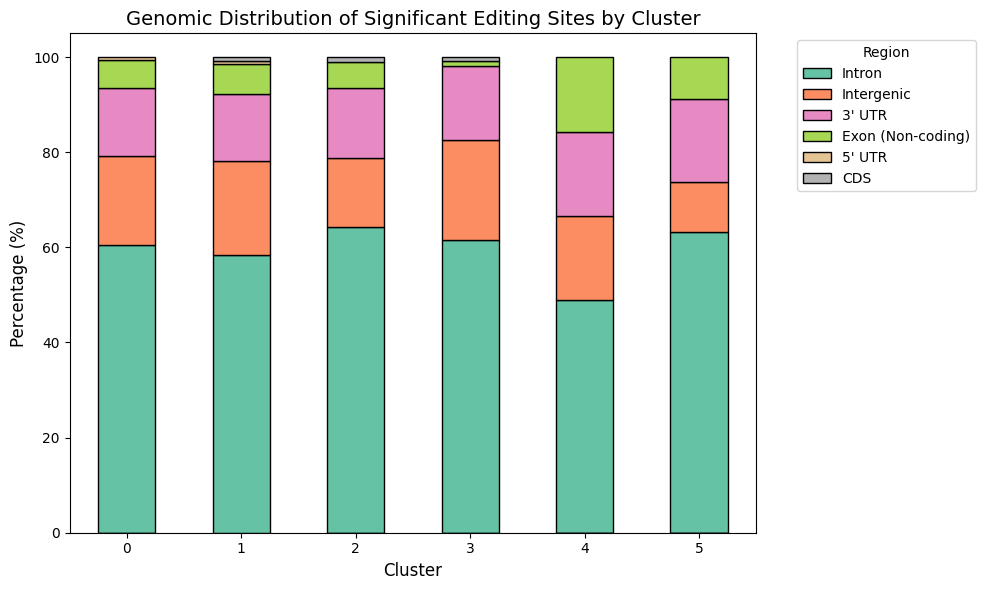

In [1]:
import pandas as pd
import gffutils
import os

# --- 配置路径 ---
gtf_path = r"C:\Users\28616\Desktop\Mus_musculus.GRCm38.93.saw.gtf"
db_path = r"C:\Users\28616\Desktop\mus_musculus.db"
results_dir = r"C:\Users\28616\Desktop\DESeq2_Results"

# 1. 建立/加载 GTF 数据库
if not os.path.exists(db_path):
    print("正在解析 GTF 文件建立地图数据库，请稍候（仅需一次）...")
    db = gffutils.create_db(gtf_path, db_path, force=True, keep_order=True,
                            merge_strategy='merge', sort_attribute_values=True)
else:
    db = gffutils.FeatureDB(db_path)

def get_region_type(chrom, pos):
    """根据坐标在 GTF 数据库中查找该位点属于什么区域"""
    try:
        features = list(db.region(seqid=str(chrom), start=pos, end=pos))
    except ValueError:
        return "Intergenic"
    
    if not features:
        return "Intergenic"

    types = [f.featuretype for f in features]
    
    # 优先级逻辑判断
    if 'CDS' in types: return 'CDS'
    if 'three_prime_utr' in types: return '3\' UTR'
    if 'five_prime_utr' in types: return '5\' UTR'
    if 'exon' in types: return 'Exon (Non-coding)'
    if 'gene' in types: return 'Intron'
    
    return "Other"

# 2. 循环处理 Cluster 0 到 5
summary_list = []

for n in range(6):
    file_name = f"DESeq2_Result_cluster{n}.csv"
    file_path = os.path.join(results_dir, file_name)
    
    if not os.path.exists(file_path):
        print(f"跳过不存在的文件: {file_name}")
        continue
    
    print(f"\n正在分析 {file_name}...")
    df = pd.read_csv(file_path)
    
    # 拆分 ID (例如 "10_10038916" -> "10" 和 10038916)
    df[['chr', 'pos']] = df.iloc[:, 0].str.split('_', expand=True)
    df['pos'] = df['pos'].astype(int)
    
    # 【核心修复区】：放弃 padj，改用 pvalue 且加上倍数过滤！
    # 自动识别 pvalue 列名
    p_col = [c for c in df.columns if 'pvalue' in c.lower() or 'p.value' in c.lower()][0]
    
    # 筛选条件：原始 P值 < 0.05 并且 差异倍数绝对值 > 1 (即差异2倍以上)
    significant_df = df[(df[p_col] < 0.05) & (df['log2FoldChange'].abs() > 1)].copy()
    
    if significant_df.empty:
        print(f"Cluster {n} 没有满足 pvalue < 0.05 且 |log2FC| > 1 的位点。")
        continue

    print(f"  -> 找到 {len(significant_df)} 个严谨的显著位点，正在映射区域...")
    # 对显著位点进行区域标注
    significant_df['Region'] = significant_df.apply(lambda x: get_region_type(x['chr'], x['pos']), axis=1)
    
    # 统计分布
    counts = significant_df['Region'].value_counts()
    summary_list.append({"Cluster": n, **counts.to_dict()})
    
    # 保存该 Cluster 的详细注释结果 (包含基因组位置信息)
    significant_df.to_csv(os.path.join(results_dir, f"Annotated_Cluster_{n}.csv"), index=False)

# 3. 输出汇总统计及计算百分比
if summary_list:
    # 填充缺失值为0
    summary_df = pd.DataFrame(summary_list).fillna(0)
    
    # 获取所有的区域名称列 (排除 'Cluster' 列)
    region_cols = [col for col in summary_df.columns if col != 'Cluster']
    
    # 计算每个 Cluster 的显著位点总数
    summary_df['Total'] = summary_df[region_cols].sum(axis=1)
    
    # 创建一个用于展示的 DataFrame
    display_df = pd.DataFrame()
    display_df['Cluster'] = summary_df['Cluster']
    display_df['Total_Sites'] = summary_df['Total'].astype(int)
    
    # 计算百分比并合并为 "数量 (百分比%)" 格式
    for col in region_cols:
        # 计算百分比 (保留两位小数)
        pct_series = (summary_df[col] / summary_df['Total'] * 100).round(2)
        
        # 将结果存入原始 df (方便保存为CSV供后续纯数据分析)
        summary_df[f'{col}_pct'] = pct_series
        
        # 拼接字符串用于直观展示，例如 "15 (25.0%)"
        display_df[col] = summary_df[col].astype(int).astype(str) + " (" + pct_series.astype(str) + "%)"

    print("\n--- 各个 Cluster 显著位点的区域分布汇总 (数量与百分比) ---")
    print(display_df.to_string(index=False)) 
    
    # 保存包含绝对数量和百分比的完整结果
    out_csv = os.path.join(results_dir, "Overall_Distribution_Summary_with_Percentage.csv")
    summary_df.to_csv(out_csv, index=False)
    
    # 保存一份好看的展示版结果
    display_df.to_csv(os.path.join(results_dir, "Overall_Distribution_Display.csv"), index=False)
    print(f"\n✅ 统计完成！详细结果已保存至:\n {out_csv}")
    
    # ==========================================
    # 4. (附赠) 绘制百分比堆叠柱状图 (Stacked Bar Plot)
    # ==========================================
    import matplotlib.pyplot as plt
    
    # 提取百分比数据用来画图
    pct_cols = [f'{col}_pct' for col in region_cols]
    plot_df = summary_df.set_index('Cluster')[pct_cols]
    # 把列名里的 '_pct' 去掉，让图例更好看
    plot_df.columns = region_cols 
    
    # 开始绘图
    ax = plot_df.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set2', edgecolor='black')
    plt.title('Genomic Distribution of Significant Editing Sites by Cluster', fontsize=14)
    plt.xlabel('Cluster', fontsize=12)
    plt.ylabel('Percentage (%)', fontsize=12)
    
    # 把图例放到图表外面右侧
    plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=0)
    plt.tight_layout()
    
    # 保存图片
    plot_path = os.path.join(results_dir, "Genomic_Distribution_StackedBar.pdf")
    plt.savefig(plot_path, format='pdf', dpi=300)
    print(f"📊 分布柱状图已保存至: {plot_path}")

else:
    print("\n⚠️ 经过严格的双重过滤，所有 Cluster 均无显著位点。")